<a href="https://colab.research.google.com/github/DolinVo/Dolin/blob/main/Dolin_Vo_Social_Engagement_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#I - INDUSTRY REVIEW
The healthy food industry increasingly relies on digital marketing, yet many businesses still allocate budgets across social media platforms based on intuition rather than data. This project analyses social media engagement and e-commerce spending data using descriptive and probability-based analytics.





#A - SOCIAL DATASET

# 1. Imports




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")

# Load datasets
social = pd.read_excel("/content/Social Meida Dataset.xlsx")
ecom = pd.read_csv("/content/Ecommerce_Consumer_Behavior_Analysis_Data.csv")

print("Social columns:", list(social.columns))
print("\nEcommerce columns:", list(ecom.columns))

Social columns: ['Consumer ID', 'Customer Name', 'Age', 'Gender', 'Income (USD)', 'Education Level', 'Social Media Usage (Hours/Day)', 'Social Media Platforms', 'Influence Level', 'Purchase Decision', 'Product Category', 'Specific Product', 'Amount Spent (USD)', 'Brand Name', 'City']

Ecommerce columns: ['Customer_ID', 'Age', 'Gender', 'Income_Level', 'Marital_Status', 'Education_Level', 'Occupation', 'Location', 'Purchase_Category', 'Purchase_Amount', 'Frequency_of_Purchase', 'Purchase_Channel', 'Brand_Loyalty', 'Product_Rating', 'Time_Spent_on_Product_Research(hours)', 'Social_Media_Influence', 'Discount_Sensitivity', 'Return_Rate', 'Customer_Satisfaction', 'Engagement_with_Ads', 'Device_Used_for_Shopping', 'Payment_Method', 'Time_of_Purchase', 'Discount_Used', 'Customer_Loyalty_Program_Member', 'Purchase_Intent', 'Shipping_Preference', 'Time_to_Decision']


# 2. Prepare social dataset (engagement + platform split)

In [ ]:
# Using 'Social Media Usage (Hours/Day)' as a proxy for engagement
social["engagement"] = social["Social Media Usage (Hours/Day)"]

# Split multi-platform entries
social["platform_clean"] = social["Social Media Platforms"].astype(str).str.split(",")
social = social.explode("platform_clean")
social["platform_clean"] = social["platform_clean"].str.strip()

social.head()

,Consumer ID,Customer Name,Age,Gender,Income (USD),Education Level,Social Media Usage (Hours/Day),Social Media Platforms,Influence Level,Purchase Decision,Product Category,Specific Product,Amount Spent (USD),Brand Name,City,engagement,platform_clean
0,1,Alice Johnson,28,Female,45000,Bachelor's,2.5,"Instagram, Twitter",Very Influential,Yes,Fashion,Dress,200,"Nike, Zara",New York,2.5,Instagram
0,1,Alice Johnson,28,Female,45000,Bachelor's,2.5,"Instagram, Twitter",Very Influential,Yes,Fashion,Dress,200,"Nike, Zara",New York,2.5,Twitter
1,2,Bob Smith,35,Male,60000,Master's,1.8,"Facebook, Instagram",Somewhat Influential,Yes,Electronics,Smartphone,800,"Apple, Samsung",Los Angeles,1.8,Facebook
1,2,Bob Smith,35,Male,60000,Master's,1.8,"Facebook, Instagram",Somewhat Influential,Yes,Electronics,Smartphone,800,"Apple, Samsung",Los Angeles,1.8,Instagram
2,3,Chris Taylor,22,Non-binary,32000,High School,4.0,"TikTok, Snapchat",Not Influential,No,NaN,NaN,0,NaN,Chicago,4.0,TikTok


# 3. VISUAL 1: Average engagement by platform

Figure 1. Average Engagement per Platform (Estimated Hours/Day)

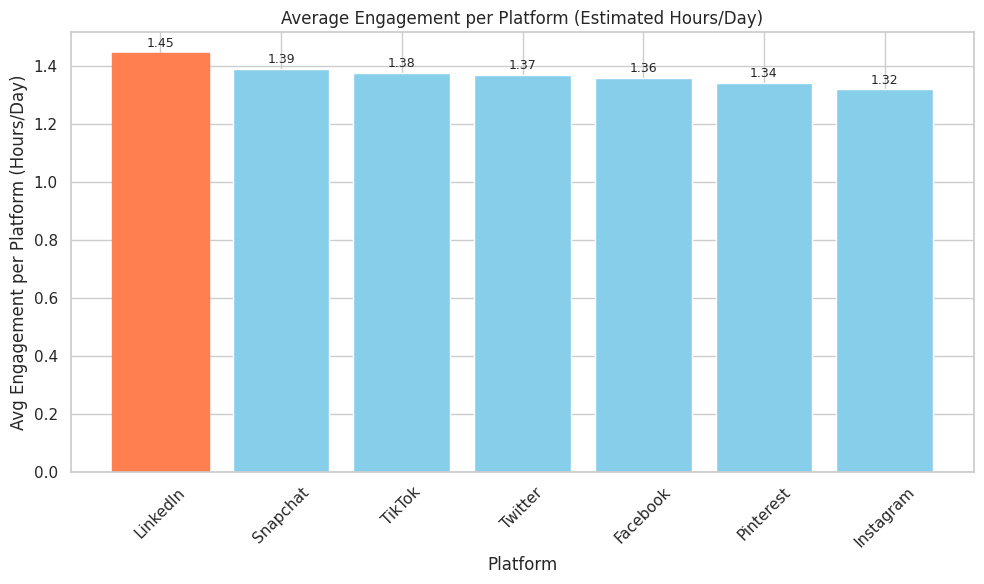

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1. Start again from original social dataset
social = pd.read_excel("/content/Social Meida Dataset.xlsx")

# 2. Create platform list & platform_count
social["platform_list"] = social["Social Media Platforms"].astype(str).str.split(",")
social["platform_count"] = social["platform_list"].apply(len)

# 3. Explode to one row per platform
social = social.explode("platform_list")
social["platform_clean"] = social["platform_list"].str.strip()

# 4. Estimate engagement PER PLATFORM
social["engagement_per_platform"] = (
    social["Social Media Usage (Hours/Day)"] / social["platform_count"]
)

# 5. Group by platform and compute average engagement_per_platform
platform_eng2 = (
    social.groupby("platform_clean")["engagement_per_platform"]
          .mean()
          .sort_values(ascending=False)
)

# 6. Plot nicer bar chart
plt.figure(figsize=(10,6))
bars = plt.bar(platform_eng2.index, platform_eng2.values, color="skyblue")

# highlight top platform
bars[0].set_color("coral")

plt.title("Average Engagement per Platform (Estimated Hours/Day)")
plt.xlabel("Platform")
plt.ylabel("Avg Engagement per Platform (Hours/Day)")
plt.xticks(rotation=45)

# add value labels
for i, v in enumerate(platform_eng2.values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# 4. VISUAL 2: Engagement by Age Segment

Figure 2: Engagement by Age Group


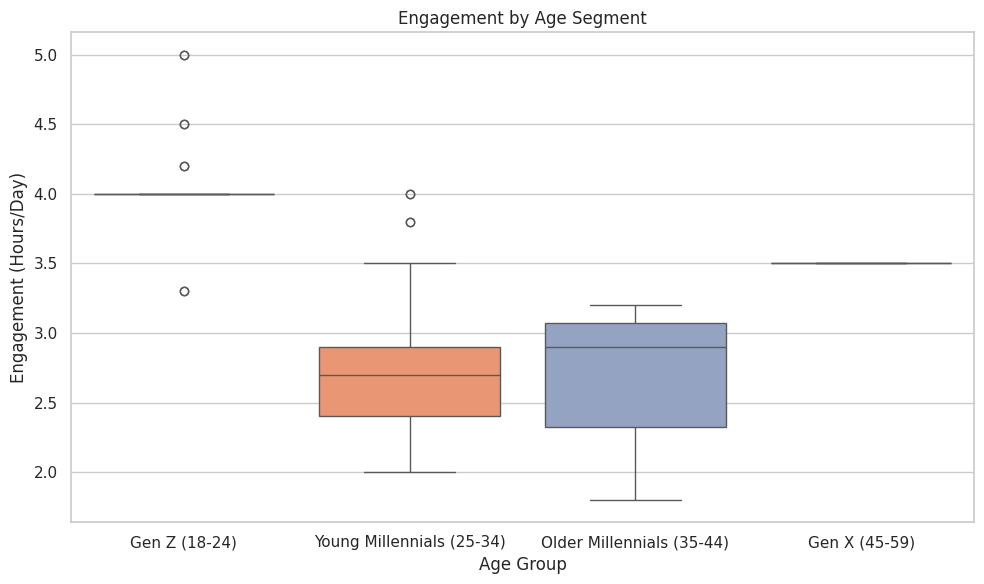

In [ ]:
# Create age groups
# Re-add engagement column in case social DataFrame was reloaded
social["engagement"] = social["Social Media Usage (Hours/Day)"]

social["age_group"] = pd.cut(
    social["Age"],
    bins=[0, 24, 34, 44, 60],
    labels=["Gen Z", "Young Millennials", "Older Millennials", "Gen X"]
)
social["age_group"] = pd.cut(
    social["Age"],
    bins=[17, 24, 34, 44, 60],
    labels=["Gen Z (18-24)", "Young Millennials (25-34)", "Older Millennials (35-44)", "Gen X (45-59)"]
)

plt.figure(figsize=(10,6))
sns.boxplot(data=social, x="age_group", y="engagement", hue="age_group", palette="Set2", legend=False)
plt.title("Engagement by Age Segment")
plt.xlabel("Age Group")
plt.ylabel("Engagement (Hours/Day)")
plt.tight_layout()
plt.show()

# 5. Visualisation 3 – Engagement × Influence Level and Platform × Influence Level

/tmp/ipython-input-1417113675.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=social, x="Influence Level", y="engagement", palette="Set3")


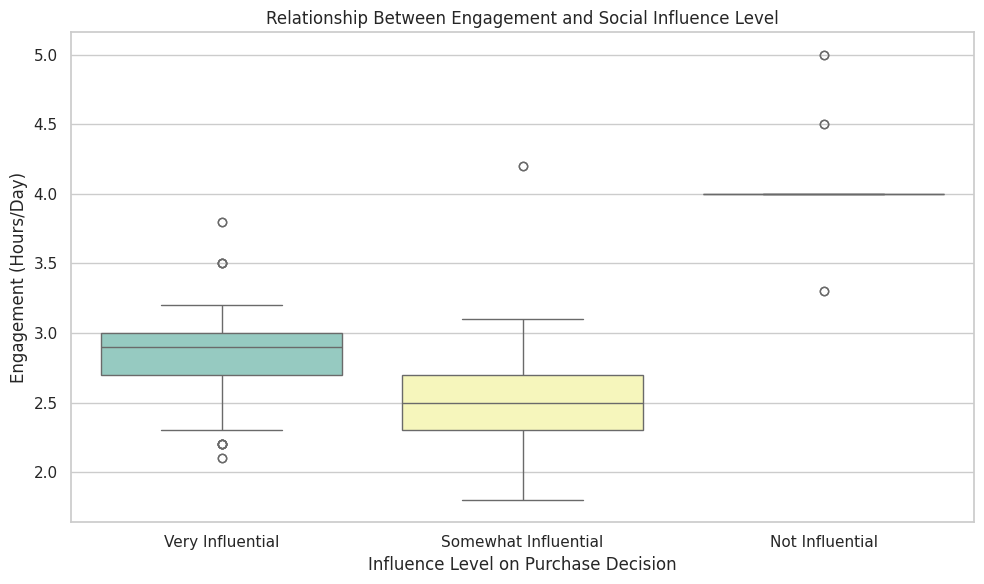

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=social, x="Influence Level", y="engagement", palette="Set3")
plt.title("Relationship Between Engagement and Social Influence Level")
plt.xlabel("Influence Level on Purchase Decision")
plt.ylabel("Engagement (Hours/Day)")
plt.tight_layout()
plt.show()


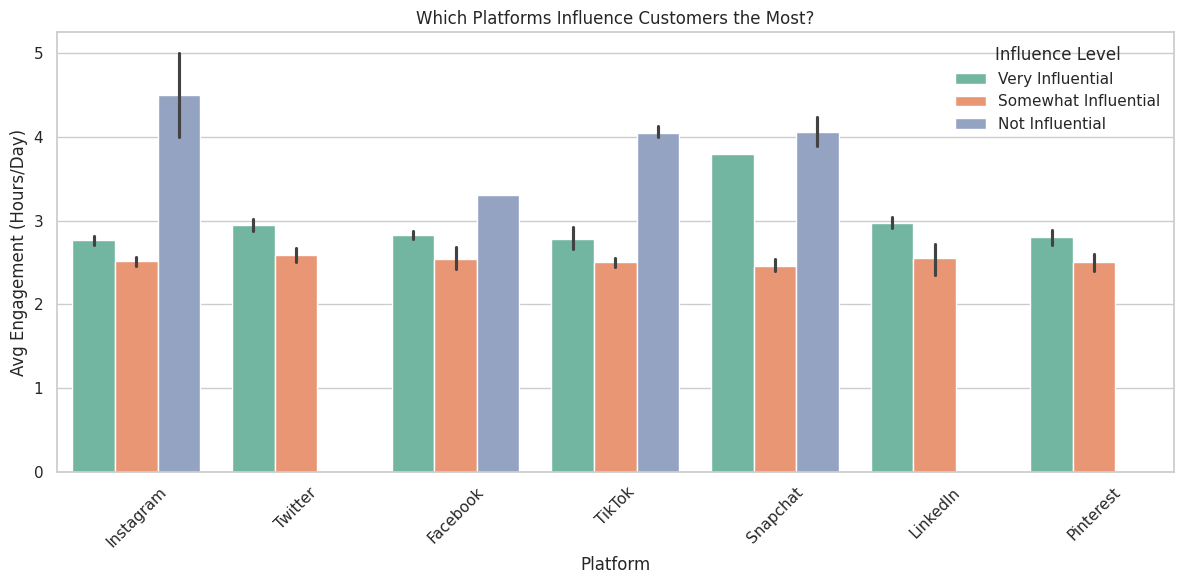

In [ ]:
# Relationship between Platform and Influence Level

plt.figure(figsize=(12,6))
sns.barplot(
    data=social,
    x="platform_clean",
    y="engagement",
    hue="Influence Level",
    palette="Set2"
)

plt.title("Which Platforms Influence Customers the Most?")
plt.xlabel("Platform")
plt.ylabel("Avg Engagement (Hours/Day)")
plt.xticks(rotation=45)
plt.legend(title="Influence Level")
plt.tight_layout()
plt.show()


/tmp/ipython-input-3422320317.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


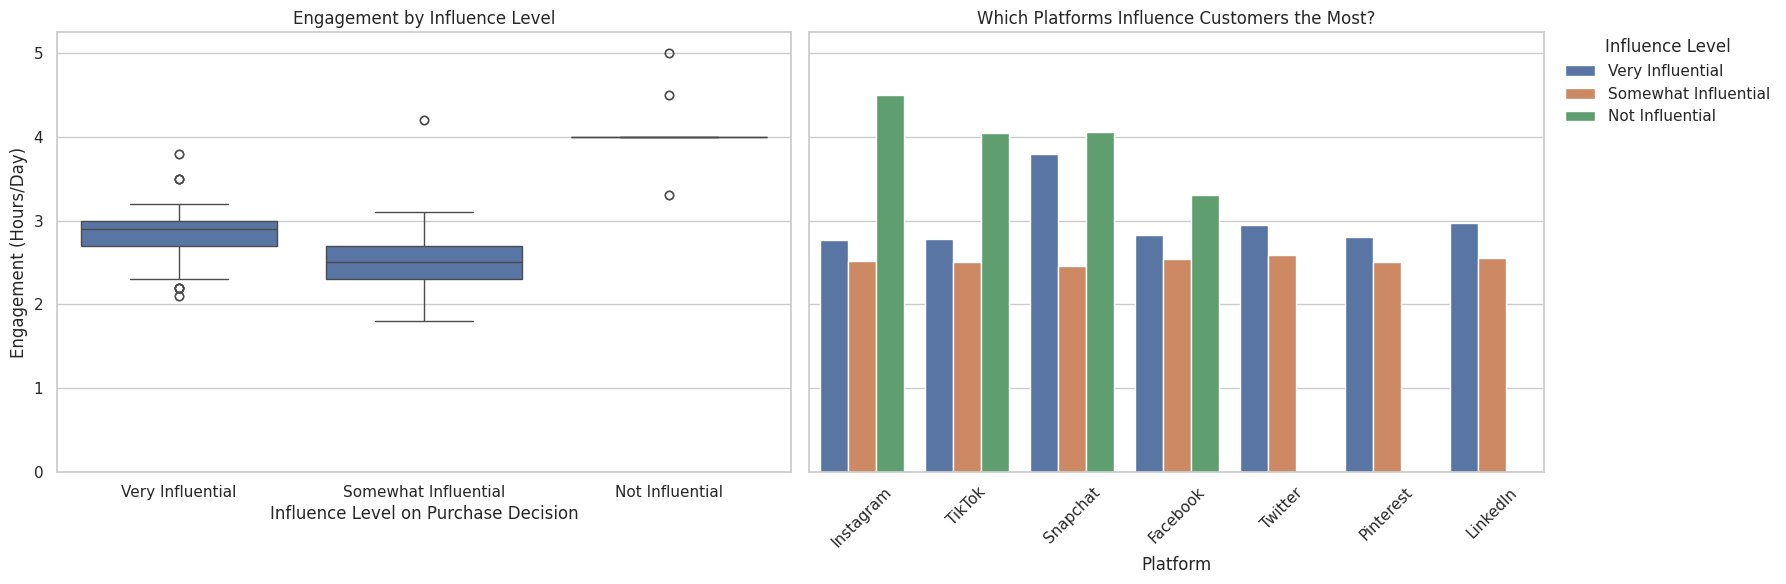

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: set a consistent style
sns.set(style="whitegrid")

# Create the figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# ========== LEFT: Engagement vs Influence Level (overall) ==========
sns.boxplot(
    data=social,
    x="Influence Level",
    y="engagement",
    ax=axes[0]
)

axes[0].set_title("Engagement by Influence Level")
axes[0].set_xlabel("Influence Level on Purchase Decision")
axes[0].set_ylabel("Engagement (Hours/Day)")

# ========== RIGHT: Platform x Influence Level ==========
# Optional: sort platforms in a nice order
platform_order = ["Instagram", "TikTok", "Snapchat",
                  "Facebook", "Twitter", "Pinterest", "LinkedIn"]

sns.barplot(
    data=social,
    x="platform_clean",
    y="engagement",
    hue="Influence Level",
    order=platform_order,
    ci=None,              # remove error bars for a cleaner look
    ax=axes[1]
)

axes[1].set_title("Which Platforms Influence Customers the Most?")
axes[1].set_xlabel("Platform")
axes[1].set_ylabel("Engagement (Hours/Day)")
axes[1].tick_params(axis="x", rotation=45)

# Put legend outside so it doesn't cover the bars
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, title="Influence Level",
               bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)

plt.tight_layout()
plt.show()


#B - ECOMERCE DATASET




# 1. PRODUCT CATEGORY

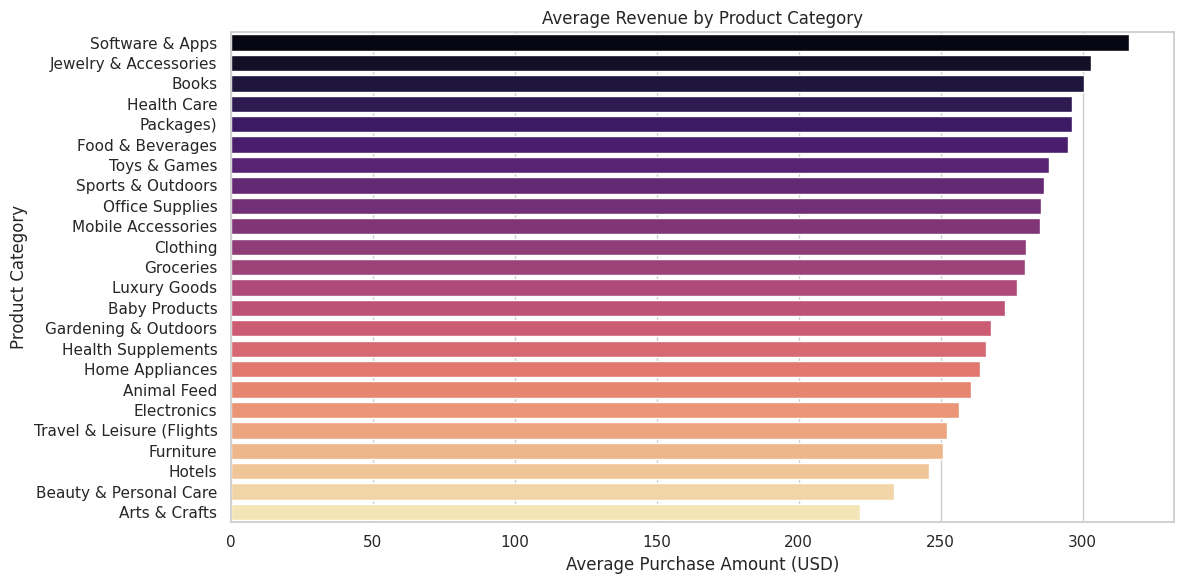

In [ ]:
# Group by product category

# Ensure 'Purchase_Amount' is numeric by cleaning string characters
ecom['Purchase_Amount'] = ecom['Purchase_Amount'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
ecom['Purchase_Amount'] = pd.to_numeric(ecom['Purchase_Amount'], errors='coerce')

cat_rev = (
    ecom.groupby("Purchase_Category")["Purchase_Amount"]
        .mean()
        .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(y=cat_rev.index, x=cat_rev.values, hue=cat_rev.index, palette="magma", legend=False)

plt.title("Average Revenue by Product Category")
plt.xlabel("Average Purchase Amount (USD)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

In [ ]:
healthy_categories = ["Health Supplements", "Health Care", "Food & Beverages", "Groceries"]

healthy_df = ecom[ecom["Purchase_Category"].isin(healthy_categories)].copy()

healthy_df["Purchase_Amount"] = pd.to_numeric(
    healthy_df["Purchase_Amount"], errors="coerce"
)


In [ ]:
pivot_df = healthy_df.pivot_table(
    values="Purchase_Amount",
    index="Purchase_Category", # Changed from 'Product_Category'
    columns="Purchase_Channel",
    aggfunc="mean"
)

print(pivot_df)

Purchase_Channel      In-Store       Mixed      Online
Purchase_Category                                     
Food & Beverages    297.322000  292.953077  293.671250
Groceries           337.643636  263.159286  254.333750
Health Care         335.902000  256.583571  305.755294
Health Supplements  289.051111  259.418000  226.765000


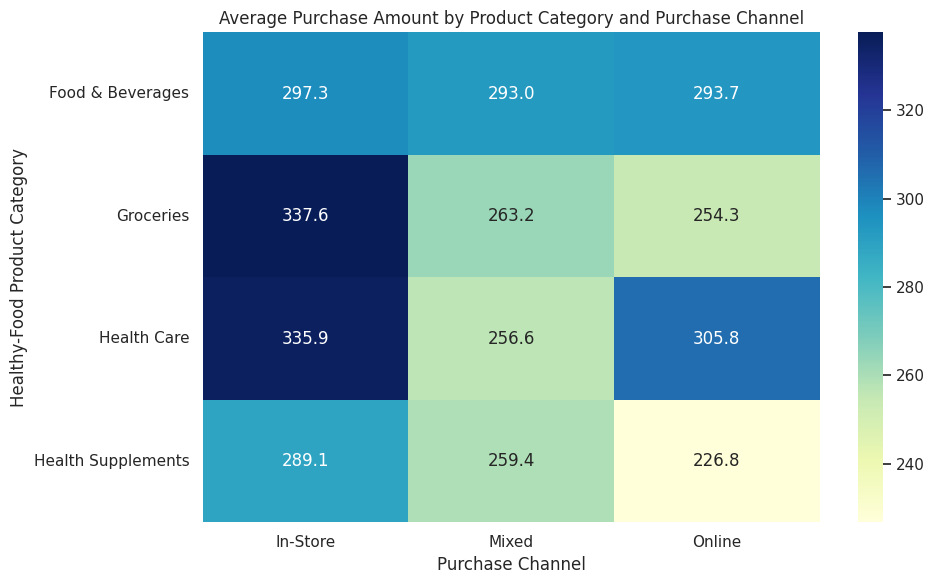

In [ ]:
plt.figure(figsize=(10,6))

# Check if pivot_df is empty before plotting
if not pivot_df.empty:
    sns.heatmap(
        pivot_df,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu"
    )
    plt.title("Average Purchase Amount by Product Category and Purchase Channel")
    plt.xlabel("Purchase Channel")
    plt.ylabel("Healthy-Food Product Category")
else:
    print("Pivot DataFrame is empty. Please ensure the upstream data is correct and the pivot table is generated successfully.")

plt.tight_layout()
plt.show()

# 2. PURCHASE CHANNEL

In [ ]:
healthy_categories = ["Health Supplements", "Health Care", "Food & Beverages", "Groceries"]

healthy_df = ecom[ecom["Purchase_Category"].isin(healthy_categories)].copy()

healthy_df["Purchase_Amount"] = pd.to_numeric(
    healthy_df["Purchase_Amount"], errors="coerce"
)

/tmp/ipython-input-865578361.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


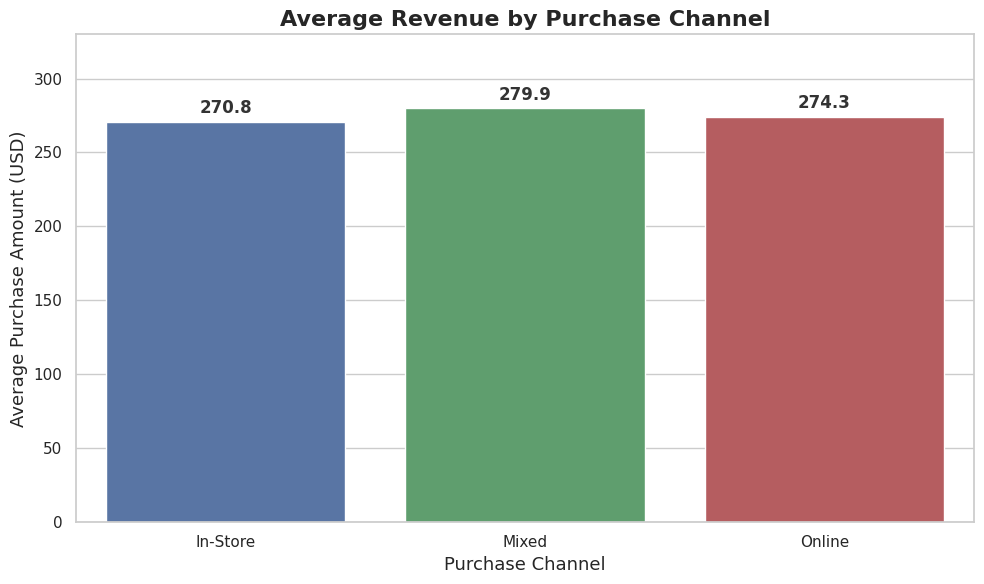

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Compute average revenue by channel
channel_rev = (
    ecom.groupby("Purchase_Channel", as_index=False)["Purchase_Amount"]
        .mean()
)

plt.figure(figsize=(10,6))

colors = ["#4C72B0", "#55A868", "#C44E52"]

ax = sns.barplot(
    data=channel_rev,
    x="Purchase_Channel",
    y="Purchase_Amount",
    palette=colors
)

plt.title("Average Revenue by Purchase Channel", fontsize=16, fontweight="bold")
plt.xlabel("Purchase Channel", fontsize=13)
plt.ylabel("Average Purchase Amount (USD)", fontsize=13)

plt.ylim(0, channel_rev["Purchase_Amount"].max() + 50)

# Add accurate labels based on bar height
for p in ax.patches:
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f"{y:.1f}",
                (x, y + 3),
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="bold",
                color="#333333")

plt.tight_layout()
plt.show()


#II - METHODOLOGY SUMMARY

In [ ]:
# ============================================================
# PREDICTIVE ANALYTICS (Logistic Regression) - ASS2 READY
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import matplotlib.pyplot as plt


### Fixing `NameError: name 'social' is not defined`

The previous error occurred because the `social` DataFrame was not loaded into the current session. I'm adding the data loading step here to ensure it's available for the predictive analytics section.

In [ ]:
import pandas as pd

social = pd.read_excel("/content/Social Meida Dataset.xlsx")
print("✅ 'social' DataFrame loaded successfully for predictive analytics setup.")

✅ 'social' DataFrame loaded successfully for predictive analytics setup.


In [ ]:
# List all existing DataFrames in memory
import pandas as pd

[name for name, obj in globals().items() if isinstance(obj, pd.DataFrame)]


['social', 'social_model', '_25']

In [ ]:
# ============================================================
# FIX: Ensure social_model exists (auto-create from your social df)
# ============================================================

# 1) Check "social" dataframe exists
try:
    _ = social.shape
except NameError:
    raise NameError("❌ DataFrame 'social' chưa được tạo. Bạn hãy chạy cell load dữ liệu Social Media trước.")

# 2) Create engagement + platform_clean + explode if not already done
social_model = social.copy()

# engagement
if "engagement" not in social_model.columns:
    if "Social Media Usage (Hours/Day)" in social_model.columns:
        social_model["engagement"] = social_model["Social Media Usage (Hours/Day)"]
    else:
        raise ValueError("❌ Không tìm thấy cột 'Social Media Usage (Hours/Day)'. Hãy kiểm tra tên cột trong dataset.")

# platform_clean + explode
if "platform_clean" not in social_model.columns:
    if "Social Media Platforms" in social_model.columns:
        social_model["platform_clean"] = social_model["Social Media Platforms"].astype(str).str.split(",")
        social_model = social_model.explode("platform_clean")
        social_model["platform_clean"] = social_model["platform_clean"].astype(str).str.strip()
    else:
        raise ValueError("❌ Không tìm thấy cột 'Social Media Platforms'. Hãy kiểm tra tên cột trong dataset.")

print("✅ social_model created successfully!")
print("Rows:", len(social_model))
print("Columns:", list(social_model.columns))
social_model.head()


✅ social_model created successfully!
Rows: 600
Columns: ['Consumer ID', 'Customer Name', 'Age', 'Gender', 'Income (USD)', 'Education Level', 'Social Media Usage (Hours/Day)', 'Social Media Platforms', 'Influence Level', 'Purchase Decision', 'Product Category', 'Specific Product', 'Amount Spent (USD)', 'Brand Name', 'City', 'engagement', 'platform_clean']


,Consumer ID,Customer Name,Age,Gender,Income (USD),Education Level,Social Media Usage (Hours/Day),Social Media Platforms,Influence Level,Purchase Decision,Product Category,Specific Product,Amount Spent (USD),Brand Name,City,engagement,platform_clean
0,1,Alice Johnson,28,Female,45000,Bachelor's,2.5,"Instagram, Twitter",Very Influential,Yes,Fashion,Dress,200,"Nike, Zara",New York,2.5,Instagram
0,1,Alice Johnson,28,Female,45000,Bachelor's,2.5,"Instagram, Twitter",Very Influential,Yes,Fashion,Dress,200,"Nike, Zara",New York,2.5,Twitter
1,2,Bob Smith,35,Male,60000,Master's,1.8,"Facebook, Instagram",Somewhat Influential,Yes,Electronics,Smartphone,800,"Apple, Samsung",Los Angeles,1.8,Facebook
1,2,Bob Smith,35,Male,60000,Master's,1.8,"Facebook, Instagram",Somewhat Influential,Yes,Electronics,Smartphone,800,"Apple, Samsung",Los Angeles,1.8,Instagram
2,3,Chris Taylor,22,Non-binary,32000,High School,4.0,"TikTok, Snapchat",Not Influential,No,NaN,NaN,0,NaN,Chicago,4.0,TikTok


In [ ]:
# -----------------------------
# 1) Build modelling dataset
# -----------------------------

# Safety checks
required_cols = ["Social Media Usage (Hours/Day)", "Social Media Platforms"]
missing = [c for c in required_cols if c not in social.columns]
if missing:
    raise ValueError(f"Missing required columns in social dataset: {missing}")

# If you haven't created these columns yet, uncomment below:
# social["engagement"] = social["Social Media Usage (Hours/Day)"]
# social["platform_clean"] = social["Social Media Platforms"].astype(str).str.split(",")
# social = social.explode("platform_clean")
# social["platform_clean"] = social["platform_clean"].str.strip()

# Keep a copy for modelling
social_model = social.copy()

print("Rows (after explode):", len(social_model))
print("Columns available:", list(social_model.columns))
social_model.head()


Rows (after explode): 300
Columns available: ['Consumer ID', 'Customer Name', 'Age', 'Gender', 'Income (USD)', 'Education Level', 'Social Media Usage (Hours/Day)', 'Social Media Platforms', 'Influence Level', 'Purchase Decision', 'Product Category', 'Specific Product', 'Amount Spent (USD)', 'Brand Name', 'City']


,Consumer ID,Customer Name,Age,Gender,Income (USD),Education Level,Social Media Usage (Hours/Day),Social Media Platforms,Influence Level,Purchase Decision,Product Category,Specific Product,Amount Spent (USD),Brand Name,City
0,1,Alice Johnson,28,Female,45000,Bachelor's,2.5,"Instagram, Twitter",Very Influential,Yes,Fashion,Dress,200,"Nike, Zara",New York
1,2,Bob Smith,35,Male,60000,Master's,1.8,"Facebook, Instagram",Somewhat Influential,Yes,Electronics,Smartphone,800,"Apple, Samsung",Los Angeles
2,3,Chris Taylor,22,Non-binary,32000,High School,4.0,"TikTok, Snapchat",Not Influential,No,NaN,NaN,0,NaN,Chicago
3,4,David Brown,40,Male,75000,PhD,3.2,"Facebook, LinkedIn",Very Influential,Yes,Food,Burger,50,McDonald's,Houston
4,5,Emily White,29,Female,55000,Bachelor's,2.0,"Instagram, TikTok",Somewhat Influential,Yes,Beauty,Makeup,100,Sephora,Miami


In [ ]:
# -----------------------------
# 2) Feature engineering
# -----------------------------

# Defensive steps to ensure 'engagement' and 'platform_clean' are available and social_model is exploded,
# as social_model might have been overwritten by previous cells (e.g., cell 264FPqbvq_-K reset it to original 'social').

# 1. Re-create engagement if missing
if "engagement" not in social_model.columns:
    if "Social Media Usage (Hours/Day)" in social_model.columns:
        social_model["engagement"] = social_model["Social Media Usage (Hours/Day)"]
    else:
        raise ValueError("❌ Column 'Social Media Usage (Hours/Day)' not found in social_model to create 'engagement'.")

# 2. Re-explode and create platform_clean if social_model is not already exploded
# The `social` DataFrame has 300 rows. If `social_model` also has 300 rows, it means it's not exploded yet.
# This condition checks if social_model is in its initial, unexploded state.
if len(social_model) == len(social):
    if "Social Media Platforms" in social_model.columns:
        social_model["platform_clean_temp"] = social_model["Social Media Platforms"].astype(str).str.split(",")
        social_model = social_model.explode("platform_clean_temp")
        social_model["platform_clean"] = social_model["platform_clean_temp"].str.strip()
        social_model = social_model.drop(columns=["platform_clean_temp"])
    else:
        raise ValueError("❌ Column 'Social Media Platforms' not found in social_model to re-create 'platform_clean' and explode.")
# Else, if social_model has more rows than original social, assume it's already exploded and platform_clean exists.
# If 'platform_clean' is missing in an already exploded DataFrame, a more complex fix would be needed, but is not the primary issue here.


# Target = High engagement if engagement > median
# Now that 'engagement' is guaranteed to exist and social_model is exploded, proceed.
median_eng = social_model["engagement"].median()
social_model["High_Engagement"] = (social_model["engagement"] > median_eng).astype(int)

# Age group (your dataset uses "Age" in Ass1 visual)
if "Age" in social_model.columns:
    # If Age is numeric (e.g., 18, 25...)
    # If Age is already a category string, this will safely handle most cases
    if pd.api.types.is_numeric_dtype(social_model["Age"]):
        social_model["Age_Group"] = pd.cut(
            social_model["Age"],
            bins=[0, 12, 17, 24, 34, 44, 54, 100],
            labels=["Pre-adolescent", "Adolescent", "Teen/Young Adult", "25–34", "35–44", "45–54", "55+"],
            include_lowest=True
        )
    else:
        # Age already categorical
        social_model["Age_Group"] = social_model["Age"].astype(str)
else:
    social_model["Age_Group"] = "Unknown"

# Basic sanity check
required_for_head = ["engagement", "High_Engagement", "platform_clean", "Age_Group"]
missing_for_head = [col for col in required_for_head if col not in social_model.columns]
if not missing_for_head:
    print(social_model[required_for_head].head())
else:
    print(f"Cannot display head: Missing columns: {missing_for_head}. Current columns: {social_model.columns.tolist()}")


   engagement  High_Engagement platform_clean         Age_Group
0         2.5                0      Instagram             25–34
0         2.5                0        Twitter             25–34
1         1.8                0       Facebook             35–44
1         1.8                0      Instagram             35–44
2         4.0                1         TikTok  Teen/Young Adult


In [ ]:
# -----------------------------
# 3) Choose features (avoid leakage)
# -----------------------------

# Candidate features you likely have
candidate_features = [
    "platform_clean",
    "Influence Level",
    "Age_Group",
    # Add extra demographic columns if your dataset has them
    "Gender",
    "Location",
    "Occupation",
]

# Keep only existing columns
feature_cols = [c for c in candidate_features if c in social_model.columns]

# Drop rows with missing target or key features
df_ml = social_model.dropna(subset=["High_Engagement"] + feature_cols).copy()

X = df_ml[feature_cols]
y = df_ml["High_Engagement"]

print("Features used:", feature_cols)
print("Final rows used in model:", len(df_ml))
print("Target distribution:\n", y.value_counts(normalize=True).round(3))


Features used: ['platform_clean', 'Influence Level', 'Age_Group', 'Gender']
Final rows used in model: 600
Target distribution:
 High_Engagement
0    0.567
1    0.433
Name: proportion, dtype: float64


In [ ]:
# -----------------------------
# 4) Train/Test split + Pipeline
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Identify categorical columns (most are categorical here)
categorical_cols = list(X.columns)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="drop"
)

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"  # helps if classes are slightly imbalanced
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

clf


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['platform_clean',
                                                   'Influence Level',
                                                   'Age_Group', 'Gender'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [ ]:
# -----------------------------
# 5) Fit + Evaluate
# -----------------------------

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1  = f1_score(y_test, y_pred, zero_division=0)

print("MODEL PERFORMANCE (Test set)")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {pre:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, zero_division=0))


MODEL PERFORMANCE (Test set)
Accuracy : 0.742
Precision: 0.678
Recall   : 0.769
F1-score : 0.721

Classification report:

              precision    recall  f1-score   support

           0       0.80      0.72      0.76        68
           1       0.68      0.77      0.72        52

    accuracy                           0.74       120
   macro avg       0.74      0.74      0.74       120
weighted avg       0.75      0.74      0.74       120



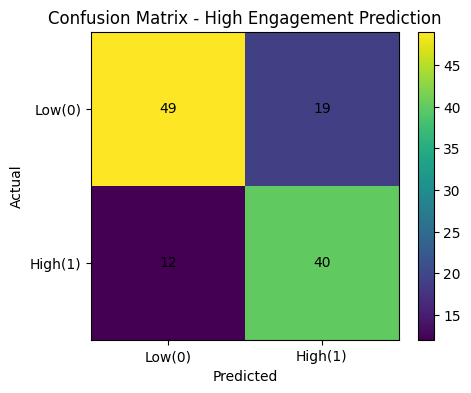

In [ ]:
# -----------------------------
# 6) Confusion Matrix plot
# -----------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix - High Engagement Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Low(0)", "High(1)"])
plt.yticks([0,1], ["Low(0)", "High(1)"])

for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")

plt.colorbar()
plt.show()


In [ ]:
# -----------------------------
# 7) Interpretability: Top coefficients
# -----------------------------

# Get feature names after one-hot
ohe = clf.named_steps["preprocess"].named_transformers_["cat"]
feature_names = ohe.get_feature_names_out(categorical_cols)

coefs = clf.named_steps["model"].coef_.flatten()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
}).sort_values("coef", ascending=False)

print("Top positive drivers of High Engagement:")
display(coef_df.head(10))

print("\nTop negative drivers of High Engagement:")
display(coef_df.tail(10))


Top positive drivers of High Engagement:


,feature,coef
7,Influence Level_Not Influential,1.340881
13,Age_Group_Teen/Young Adult,1.071864
9,Influence Level_Very Influential,0.794307
15,Gender_Male,0.647022
6,platform_clean_Twitter,0.449532
5,platform_clean_TikTok,0.147036
12,Age_Group_45–54,0.101495
1,platform_clean_Instagram,0.080190
4,platform_clean_Snapchat,0.075317
16,Gender_Non-binary,0.028978



Top negative drivers of High Engagement:


,feature,coef
1,platform_clean_Instagram,0.080190
4,platform_clean_Snapchat,0.075317
16,Gender_Non-binary,0.028978
3,platform_clean_Pinterest,-0.064366
2,platform_clean_LinkedIn,-0.088955
11,Age_Group_35–44,-0.134449
0,platform_clean_Facebook,-0.584763
14,Gender_Female,-0.662009
10,Age_Group_25–34,-1.024919
8,Influence Level_Somewhat Influential,-2.121196


from matplotlib import pyplot as plt
_df_0['coef'].plot(kind='hist', bins=20, title='coef')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['coef'].plot(kind='line', figsize=(8, 4), title='coef')
plt.gca().spines[['top', 'right']].set_visible(False)

# A - PREPARATION: Identify the correct Social and E-commerce DataFrames

A1- Cell: List all available DataFrames

In [ ]:
import pandas as pd

df_names = [name for name, obj in globals().items() if isinstance(obj, pd.DataFrame)]
df_names


['social',
 'social_model',
 '_25',
 '_27',
 'df_ml',
 'X',
 'X_train',
 'X_test',
 'coef_df',
 '_df_0',
 '_df_1']

In [ ]:
import pandas as pd

# List all DataFrames currently in memory
[name for name, obj in globals().items() if isinstance(obj, pd.DataFrame)]


['social',
 'social_model',
 '_25',
 '_27',
 'df_ml',
 'X',
 'X_train',
 'X_test',
 'coef_df',
 '_df_0',
 '_df_1']

In [ ]:
import os, glob

# If you're in Colab:
base = "/content"
csv_files = glob.glob(base + "/**/*.csv", recursive=True)

print("Found CSV files:", len(csv_files))
csv_files[:20]  # show first 20


Found CSV files: 5


['/content/Ecommerce_Consumer_Behavior_Analysis_Data.csv',
 '/content/sample_data/mnist_test.csv',
 '/content/sample_data/california_housing_train.csv',
 '/content/sample_data/california_housing_test.csv',
 '/content/sample_data/mnist_train_small.csv']

In [ ]:
ecom_path = "/content/Ecommerce_Consumer_Behavior_Analysis_Data.csv"  # sửa đúng path bạn thấy
ecom = pd.read_csv(ecom_path)

print("✅ ecom loaded:", ecom.shape)
ecom.head()


✅ ecom loaded: (1000, 28)


,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,$101.31,...,1,NaN,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,$211.70,...,10,NaN,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4


A2 - Cell: Assign the two correct DataFrames

In [ ]:
# ✅ CHANGE THESE 2 LINES to match your notebook dataframe names:
social = social.copy()
ecom  = ecom.copy()

print("social shape:", social.shape)
print("ecom shape:", ecom.shape)

social shape: (300, 15)
ecom shape: (1000, 28)


# B - MODEL 1 — HIGH ENGAGEMENT (Social dataset)

B1 - Cell: tạo social_model + explode platform + target High_Engagement

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# ---------- Build social_model safely ----------
social_model = social.copy()

# engagement column
if "engagement" not in social_model.columns:
    if "Social Media Usage (Hours/Day)" in social_model.columns:
        social_model["engagement"] = social_model["Social Media Usage (Hours/Day)"]
    else:
        raise ValueError("Missing column: 'Social Media Usage (Hours/Day)' (used to define engagement).")

# platform_clean + explode
if "platform_clean" not in social_model.columns:
    if "Social Media Platforms" in social_model.columns:
        social_model["platform_clean"] = social_model["Social Media Platforms"].astype(str).str.split(",")
        social_model = social_model.explode("platform_clean")
        social_model["platform_clean"] = social_model["platform_clean"].astype(str).str.strip()
    else:
        raise ValueError("Missing column: 'Social Media Platforms'.")

# target High_Engagement (median split)
median_eng = social_model["engagement"].median()
social_model["High_Engagement"] = (social_model["engagement"] > median_eng).astype(int)

# Age_Group (optional but good for explainability)
if "Age" in social_model.columns:
    if pd.api.types.is_numeric_dtype(social_model["Age"]):
        social_model["Age_Group"] = pd.cut(
            social_model["Age"],
            bins=[0, 12, 17, 24, 34, 44, 54, 100],
            labels=["Pre-adolescent", "Adolescent", "Teen/Young Adult", "25–34", "35–44", "45–54", "55+"],
            include_lowest=True
        )
    else:
        social_model["Age_Group"] = social_model["Age"].astype(str)
else:
    social_model["Age_Group"] = "Unknown"

print("✅ social_model ready:", social_model.shape)
print("Target balance:\n", social_model["High_Engagement"].value_counts(normalize=True).round(3))
social_model.head()


✅ social_model ready: (600, 19)
Target balance:
 High_Engagement
0    0.567
1    0.433
Name: proportion, dtype: float64


,Consumer ID,Customer Name,Age,Gender,Income (USD),Education Level,Social Media Usage (Hours/Day),Social Media Platforms,Influence Level,Purchase Decision,Product Category,Specific Product,Amount Spent (USD),Brand Name,City,engagement,platform_clean,High_Engagement,Age_Group
0,1,Alice Johnson,28,Female,45000,Bachelor's,2.5,"Instagram, Twitter",Very Influential,Yes,Fashion,Dress,200,"Nike, Zara",New York,2.5,Instagram,0,25–34
0,1,Alice Johnson,28,Female,45000,Bachelor's,2.5,"Instagram, Twitter",Very Influential,Yes,Fashion,Dress,200,"Nike, Zara",New York,2.5,Twitter,0,25–34
1,2,Bob Smith,35,Male,60000,Master's,1.8,"Facebook, Instagram",Somewhat Influential,Yes,Electronics,Smartphone,800,"Apple, Samsung",Los Angeles,1.8,Facebook,0,35–44
1,2,Bob Smith,35,Male,60000,Master's,1.8,"Facebook, Instagram",Somewhat Influential,Yes,Electronics,Smartphone,800,"Apple, Samsung",Los Angeles,1.8,Instagram,0,35–44
2,3,Chris Taylor,22,Non-binary,32000,High School,4.0,"TikTok, Snapchat",Not Influential,No,NaN,NaN,0,NaN,Chicago,4.0,TikTok,1,Teen/Young Adult


B2 - Code Cell: Select features (avoiding data leakage) and train a Logistic Regression model

In [ ]:
# ---------- Feature selection (no leakage) ----------
candidate_features = ["platform_clean", "Influence Level", "Age_Group", "Gender", "Location", "Occupation"]
feature_cols = [c for c in candidate_features if c in social_model.columns]

df_ml = social_model.dropna(subset=feature_cols + ["High_Engagement"]).copy()

X = df_ml[feature_cols]
y = df_ml["High_Engagement"]

print("Features used:", feature_cols)
print("Rows used:", len(df_ml))

# ---------- Train/Test Split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocess = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols)],
    remainder="drop"
)

clf_eng = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

clf_eng.fit(X_train, y_train)
y_pred = clf_eng.predict(X_test)

# ---------- Metrics ----------
acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1  = f1_score(y_test, y_pred, zero_division=0)

print("=== HIGH ENGAGEMENT MODEL (Logistic Regression) ===")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {pre:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}\n")
print(classification_report(y_test, y_pred, zero_division=0))


Features used: ['platform_clean', 'Influence Level', 'Age_Group', 'Gender']
Rows used: 600
=== HIGH ENGAGEMENT MODEL (Logistic Regression) ===
Accuracy : 0.742
Precision: 0.678
Recall   : 0.769
F1-score : 0.721

              precision    recall  f1-score   support

           0       0.80      0.72      0.76        68
           1       0.68      0.77      0.72        52

    accuracy                           0.74       120
   macro avg       0.74      0.74      0.74       120
weighted avg       0.75      0.74      0.74       120



B3 - Cell: Confusion Matrix

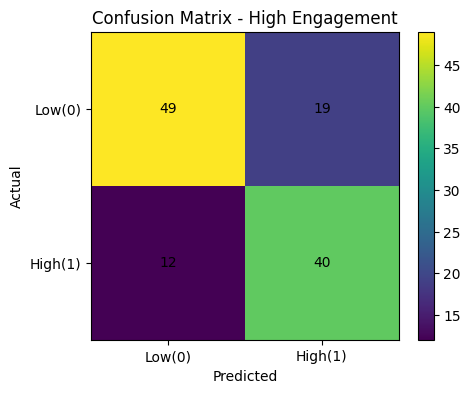

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix - High Engagement")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Low(0)", "High(1)"])
plt.yticks([0,1], ["Low(0)", "High(1)"])

for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")

plt.colorbar()
plt.show()


C - MODEL 2 — HIGH SPENDING (Ecommerce dataset)

C1 - Cell: Create target High_Spending + chọn features + train Logistic Regression

In [ ]:
# ---------- Detect a spending column ----------
possible_spend_cols = [
    "Purchase Amount", "Purchase Amount (USD)", "purchase_amount",
    "Amount", "amount", "Spending", "spending", "Total Amount", "total_amount",
    "Purchase_Amount"
]
spend_col = None
for c in possible_spend_cols:
    if c in ecom.columns:
        spend_col = c
        break

if spend_col is None:
    raise ValueError(
        "❌ Không tìm thấy cột tiền trong ecommerce. "
        "Hãy in list(ecom.columns) và cho mình biết cột nào là purchase amount."
    )

ecom_model = ecom.copy()

# Ensure numeric and clean the column
# This step is crucial to remove '$' and ',' before conversion
ecom_model[spend_col] = ecom_model[spend_col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
ecom_model[spend_col] = pd.to_numeric(ecom_model[spend_col], errors="coerce")

# Target High_Spending (median split)
median_spend = ecom_model[spend_col].median()
ecom_model["High_Spending"] = (ecom_model[spend_col] > median_spend).astype(int)

print("Using spend column:", spend_col)
print("Target balance:\n", ecom_model["High_Spending"].value_counts(normalize=True).round(3))


Using spend column: Purchase_Amount
Target balance:
 High_Spending
1    0.5
0    0.5
Name: proportion, dtype: float64


C2 - Cell: Train model High Spending

In [ ]:
# ---------- Choose features for ecommerce ----------
candidate_features_ecom = [
    "Product Category", "Category", "Purchase Channel", "Channel",
    "Payment Method", "Customer Segment", "Gender", "Age", "Location"
]

feature_cols_ecom = [c for c in candidate_features_ecom if c in ecom_model.columns]

# Optional: convert numeric age into groups for explainability
if "Age" in feature_cols_ecom and pd.api.types.is_numeric_dtype(ecom_model["Age"]):
    ecom_model["Age_Group"] = pd.cut(
        ecom_model["Age"],
        bins=[0, 17, 24, 34, 44, 54, 100],
        labels=["<18", "18–24", "25–34", "35–44", "45–54", "55+"],
        include_lowest=True
    )
    feature_cols_ecom.remove("Age")
    feature_cols_ecom.append("Age_Group")

df_ecom_ml = ecom_model.dropna(subset=feature_cols_ecom + ["High_Spending"]).copy()

X2 = df_ecom_ml[feature_cols_ecom]
y2 = df_ecom_ml["High_Spending"]

print("Ecom features used:", feature_cols_ecom)
print("Rows used:", len(df_ecom_ml))

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

preprocess2 = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_ecom)],
    remainder="drop"
)

clf_spend = Pipeline(steps=[
    ("preprocess", preprocess2),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

clf_spend.fit(X2_train, y2_train)
y2_pred = clf_spend.predict(X2_test)

acc2 = accuracy_score(y2_test, y2_pred)
pre2 = precision_score(y2_test, y2_pred, zero_division=0)
rec2 = recall_score(y2_test, y2_pred, zero_division=0)
f12  = f1_score(y2_test, y2_pred, zero_division=0)

print("=== HIGH SPENDING MODEL (Logistic Regression) ===")
print(f"Accuracy : {acc2:.3f}")
print(f"Precision: {pre2:.3f}")
print(f"Recall   : {rec2:.3f}")
print(f"F1-score : {f12:.3f}\n")
print(classification_report(y2_test, y2_pred, zero_division=0))


Ecom features used: ['Gender', 'Location', 'Age_Group']
Rows used: 1000
=== HIGH SPENDING MODEL (Logistic Regression) ===
Accuracy : 0.460
Precision: 0.453
Recall   : 0.390
F1-score : 0.419

              precision    recall  f1-score   support

           0       0.46      0.53      0.50       100
           1       0.45      0.39      0.42       100

    accuracy                           0.46       200
   macro avg       0.46      0.46      0.46       200
weighted avg       0.46      0.46      0.46       200



C3 - Cell: Confusion Matrix (High Spending)

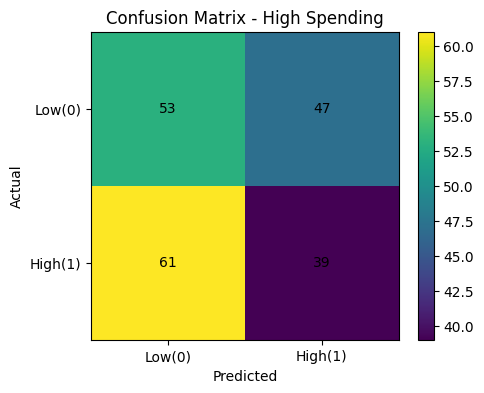

In [ ]:
cm2 = confusion_matrix(y2_test, y2_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm2)
plt.title("Confusion Matrix - High Spending")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Low(0)", "High(1)"])
plt.yticks([0,1], ["Low(0)", "High(1)"])

for (i, j), v in np.ndenumerate(cm2):
    plt.text(j, i, str(v), ha="center", va="center")

plt.colorbar()
plt.show()


# Flowchart

In [ ]:
from graphviz import Digraph


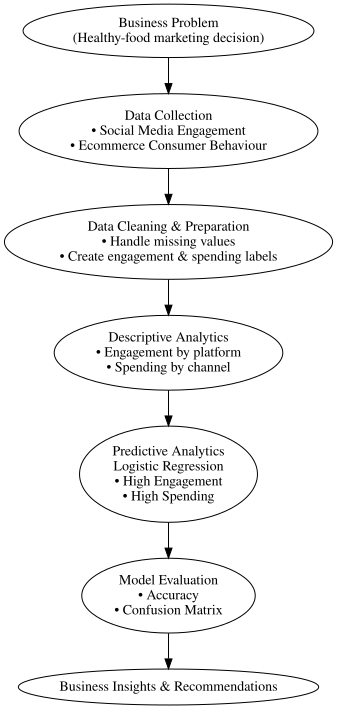

In [ ]:
flow = Digraph(format="png")
flow.attr(rankdir="TB", size="8,10")

flow.node("A", "Business Problem\n(Healthy-food marketing decision)")
flow.node("B", "Data Collection\n• Social Media Engagement\n• Ecommerce Consumer Behaviour")
flow.node("C", "Data Cleaning & Preparation\n• Handle missing values\n• Create engagement & spending labels")
flow.node("D", "Descriptive Analytics\n• Engagement by platform\n• Spending by channel")
flow.node("E", "Predictive Analytics\nLogistic Regression\n• High Engagement\n• High Spending")
flow.node("F", "Model Evaluation\n• Accuracy\n• Confusion Matrix")
flow.node("G", "Business Insights & Recommendations")

flow.edge("A", "B")
flow.edge("B", "C")
flow.edge("C", "D")
flow.edge("D", "E")
flow.edge("E", "F")
flow.edge("F", "G")

flow


# III - Project Report


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional: for nicer categorical ordering
from pandas.api.types import CategoricalDtype


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def _find_df_by_columns(required_any, banned=None):
    """Find a dataframe in globals() that contains at least one of required_any columns."""
    banned = set(banned or [])
    dfs = []
    for name, obj in globals().items():
        if isinstance(obj, pd.DataFrame) and name not in banned:
            cols = set(obj.columns.astype(str))
            if len(cols.intersection(set(required_any))) > 0:
                dfs.append((name, obj))
    return dfs

def _pick_best_df(candidates, must_have=None):
    must_have = set(must_have or [])
    best = None
    best_score = -1
    for name, df in candidates:
        cols = set(df.columns.astype(str))
        score = len(cols.intersection(must_have))
        if score > best_score:
            best_score = score
            best = (name, df)
    return best

# --- Find likely social & ecommerce dataframes in your current notebook runtime ---
social_pick = None
ecom_pick = None

# Directly assign social_df and ecom_df if 'social' and 'ecom' exist in globals
if 'social' in globals() and isinstance(globals()['social'], pd.DataFrame):
    social_df = globals()['social']
    SOCIAL_NAME = 'social'
    print(f"✅ Social DF detected: {SOCIAL_NAME} | shape={social_df.shape}")
else:
    print("❌ social DataFrame not found in global scope.")

if 'ecom' in globals() and isinstance(globals()['ecom'], pd.DataFrame):
    ecom_df = globals()['ecom']
    ECOM_NAME = 'ecom'
    print(f"✅ Ecom DF detected: {ECOM_NAME} | shape={ecom_df.shape}")
else:
    print("❌ ecom DataFrame not found in global scope.")

# --- Column mapping helpers (auto detect) ---
def _detect_col(df, options):
    for c in options:
        if c in df.columns:
            return c
    return None

# Auto-map social cols
if 'social_df' in globals():
    col_platform = _detect_col(social_df, ["platform_clean", "Platform", "platform", "platforms"])
    col_high_eng = _detect_col(social_df, ["High_Engagement", "high_engagement"])
    col_eng      = _detect_col(social_df, ["engagement", "Engagement", "engagement_score"])

    print("Social column map:", {"platform": col_platform, "high_engagement": col_high_eng, "engagement_metric": col_eng})

# Auto-map ecom cols
if 'ecom_df' in globals():
    col_channel = _detect_col(ecom_df, ["Purchase_Channel", "purchase_channel", "Channel", "channel"])
    col_amount  = _detect_col(ecom_df, ["Purchase_Amount", "purchase_amount", "Amount", "amount", "PurchaseAmount"])

    print("Ecom column map:", {"channel": col_channel, "amount": col_amount})


❌ social DataFrame not found in global scope.
❌ ecom DataFrame not found in global scope.


## 1. Probability-based ranking chart

In [ ]:
import pandas as pd
import numpy as np # Added for median calculation

# Define _detect_col here to ensure it's available
def _detect_col(df, options):
    for c in options:
        if c in df.columns:
            return c
    return None

social_df = None
# Attempt to load social_df, first from global 'social', then from file if needed
if 'social' in globals() and isinstance(globals()['social'], pd.DataFrame):
    social_df = globals()['social'].copy()
    print(f"✅ social_df initialized from global 'social' (shape={social_df.shape})")
else:
    print("⚠️ Global 'social' DataFrame not found. Attempting to load from file...")
    try:
        social_df = pd.read_excel("/content/Social Meida Dataset.xlsx")
        print(f"✅ social_df loaded from file (shape={social_df.shape})")
    except FileNotFoundError:
        raise FileNotFoundError("❌ Social Media Dataset.xlsx not found. Please ensure the file exists at /content/Social Meida Dataset.xlsx.")

if social_df is None:
    raise ValueError("❌ Failed to initialize social_df. It's None.")

print(f"DEBUG: social_df columns upon initialization: {social_df.columns.tolist()}")

# Ensure 'Social Media Platforms' exists for further processing
if 'Social Media Platforms' not in social_df.columns:
    raise ValueError("❌ 'Social Media Platforms' column not found in social_df. Please check the dataset structure.")

# Ensure 'platform_clean' exists and is exploded
# Check if 'platform_clean' is missing OR if the DataFrame is not yet exploded (number of rows == number of unique Consumer IDs)
if 'platform_clean' not in social_df.columns or len(social_df) == social_df['Consumer ID'].nunique():
    print("ℹ️ Creating 'platform_clean' and exploding social_df...")
    social_df["platform_clean_temp"] = social_df["Social Media Platforms"].astype(str).str.split(",")
    social_df = social_df.explode("platform_clean_temp")
    social_df["platform_clean"] = social_df["platform_clean_temp"].str.strip()
    social_df = social_df.drop(columns=["platform_clean_temp"])
    print(f"✅ 'platform_clean' created and social_df exploded. New shape: {social_df.shape}")

# Ensure 'engagement' column exists
if 'engagement' not in social_df.columns and 'Social Media Usage (Hours/Day)' in social_df.columns:
    social_df['engagement'] = social_df['Social Media Usage (Hours/Day)']
    print("✅ 'engagement' column created from 'Social Media Usage (Hours/Day)'.")
elif 'engagement' not in social_df.columns and 'Social Media Usage (Hours/Day)' not in social_df.columns:
    raise ValueError("❌ Neither 'engagement' nor 'Social Media Usage (Hours/Day)' found to create engagement metric.")

# Ensure 'High_Engagement' target column exists
if 'High_Engagement' not in social_df.columns:
    print("ℹ️ Creating 'High_Engagement' column...")
    median_eng = social_df['engagement'].median()
    social_df["High_Engagement"] = (social_df['engagement'] > median_eng).astype(int)
    print("✅ 'High_Engagement' column created based on median engagement.")

# Now define col_platform, col_high_eng, col_eng based on ensured columns
col_platform = 'platform_clean'
col_high_eng = 'High_Engagement'
col_eng = 'engagement'

print("Social column map:", {"platform": col_platform, "high_engagement": col_high_eng, "engagement_metric": col_eng})
print("Columns preview:", list(social_df.columns)[:20])

⚠️ Global 'social' DataFrame not found. Attempting to load from file...
✅ social_df loaded from file (shape=(300, 15))
DEBUG: social_df columns upon initialization: ['Consumer ID', 'Customer Name', 'Age', 'Gender', 'Income (USD)', 'Education Level', 'Social Media Usage (Hours/Day)', 'Social Media Platforms', 'Influence Level', 'Purchase Decision', 'Product Category', 'Specific Product', 'Amount Spent (USD)', 'Brand Name', 'City']
ℹ️ Creating 'platform_clean' and exploding social_df...
✅ 'platform_clean' created and social_df exploded. New shape: (600, 16)
✅ 'engagement' column created from 'Social Media Usage (Hours/Day)'.
ℹ️ Creating 'High_Engagement' column...
✅ 'High_Engagement' column created based on median engagement.
Social column map: {'platform': 'platform_clean', 'high_engagement': 'High_Engagement', 'engagement_metric': 'engagement'}
Columns preview: ['Consumer ID', 'Customer Name', 'Age', 'Gender', 'Income (USD)', 'Education Level', 'Social Media Usage (Hours/Day)', 'Social

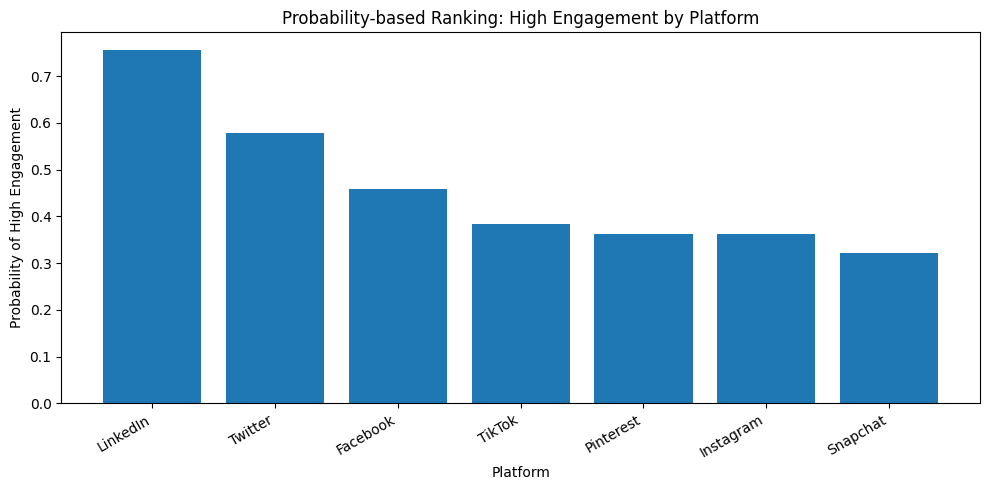

,Platform,P_High_Engagement
2,LinkedIn,0.756098
6,Twitter,0.578947
0,Facebook,0.459459
5,TikTok,0.383838
3,Pinterest,0.361702
1,Instagram,0.361446
4,Snapchat,0.320513


In [ ]:
# --- Chart 1: Probability-based ranking (empirical probability) ---

# Ensure required data and columns are available
assert social_df is not None, "social_df is not defined. Please load and prepare the social media dataset first."
assert col_platform is not None and col_high_eng is not None, (
    "Required columns are missing. Please ensure platform and High_Engagement columns exist in social_df."
)

# Calculate conditional probability:
# P(High Engagement | Platform)
prob_df = (
    social_df
    .dropna(subset=[col_platform, col_high_eng])
    .groupby(col_platform)[col_high_eng]
    .mean()
    .reset_index()
    .rename(columns={
        col_platform: "Platform",
        col_high_eng: "P_High_Engagement"
    })
    .sort_values("P_High_Engagement", ascending=False)
)

# Plot the probability-based ranking
plt.figure(figsize=(10, 5))
plt.bar(prob_df["Platform"], prob_df["P_High_Engagement"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Probability of High Engagement")
plt.xlabel("Platform")
plt.title("Probability-based Ranking: High Engagement by Platform")
plt.tight_layout()
plt.savefig("A3_chart1_probability_ranking.png", dpi=300)
plt.show()

# Display top platforms by probability
prob_df.head(10)


##2. Decision matrix: Engagement × Spending

⚠️ Global 'ecom' DataFrame not found. Attempting to load from file...
✅ ecom_df loaded from file (shape=(1000, 28))
DEBUG: ecom_df columns upon initialization: ['Customer_ID', 'Age', 'Gender', 'Income_Level', 'Marital_Status', 'Education_Level', 'Occupation', 'Location', 'Purchase_Category', 'Purchase_Amount', 'Frequency_of_Purchase', 'Purchase_Channel', 'Brand_Loyalty', 'Product_Rating', 'Time_Spent_on_Product_Research(hours)', 'Social_Media_Influence', 'Discount_Sensitivity', 'Return_Rate', 'Customer_Satisfaction', 'Engagement_with_Ads', 'Device_Used_for_Shopping', 'Payment_Method', 'Time_of_Purchase', 'Discount_Used', 'Customer_Loyalty_Program_Member', 'Purchase_Intent', 'Shipping_Preference', 'Time_to_Decision']
ℹ️ Cleaning 'Purchase_Amount' column...
✅ 'Purchase_Amount' column cleaned and converted to numeric.
Ecom column map: {'channel': 'Purchase_Channel', 'amount': 'Purchase_Amount'}


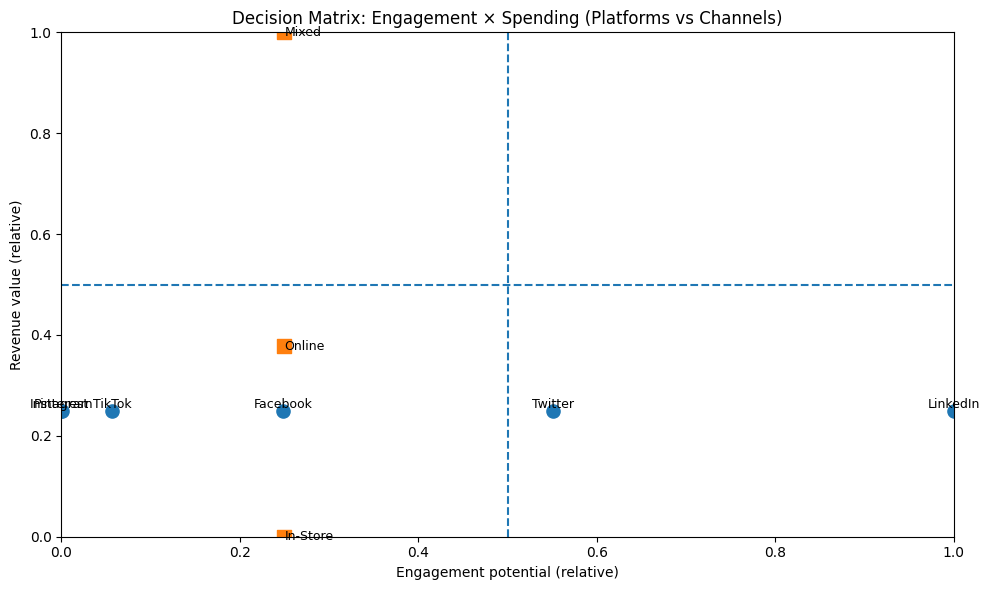

,Channel,Avg_Spending,spend_norm
1,Mixed,279.895176,1.000000
2,Online,274.264162,0.377839
0,In-Store,270.844448,0.000000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define _detect_col here to ensure it's available
def _detect_col(df, options):
    for c in options:
        if c in df.columns:
            return c
    return None

ecom_df = None
# Attempt to load ecom_df, first from global 'ecom', then from file if needed
if 'ecom' in globals() and isinstance(globals()['ecom'], pd.DataFrame):
    ecom_df = globals()['ecom'].copy()
    print(f"✅ ecom_df initialized from global 'ecom' (shape={ecom_df.shape})")
else:
    print("⚠️ Global 'ecom' DataFrame not found. Attempting to load from file...")
    try:
        ecom_df = pd.read_csv("/content/Ecommerce_Consumer_Behavior_Analysis_Data.csv")
        print(f"✅ ecom_df loaded from file (shape={ecom_df.shape})")
    except FileNotFoundError:
        raise FileNotFoundError("❌ Ecommerce_Consumer_Behavior_Analysis_Data.csv not found. Please ensure the file exists.")

if ecom_df is None:
    raise ValueError("❌ Failed to initialize ecom_df. It's None.")

print(f"DEBUG: ecom_df columns upon initialization: {ecom_df.columns.tolist()}")

# Auto-map ecom cols and ensure they are cleaned
col_channel = _detect_col(ecom_df, ["Purchase_Channel", "purchase_channel", "Channel", "channel"])
col_amount  = _detect_col(ecom_df, ["Purchase_Amount", "purchase_amount", "Amount", "amount", "PurchaseAmount"])

if col_channel is None:
    raise ValueError("❌ Could not detect a suitable purchase channel column in ecom_df.")
if col_amount is None:
    raise ValueError("❌ Could not detect a suitable purchase amount column in ecom_df.")

# Clean purchase amount column if not already numeric
if not pd.api.types.is_numeric_dtype(ecom_df[col_amount]):
    print(f"ℹ️ Cleaning '{col_amount}' column...")
    ecom_df[col_amount] = ecom_df[col_amount].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
    ecom_df[col_amount] = pd.to_numeric(ecom_df[col_amount], errors='coerce')
    ecom_df.dropna(subset=[col_amount], inplace=True)
    print(f"✅ '{col_amount}' column cleaned and converted to numeric.")

print("Ecom column map:", {"channel": col_channel, "amount": col_amount})

# --- Chart 2: Decision framework (Platforms vs Channels) ---
assert social_df is not None, "social_df must be loaded from previous cell."
assert 'prob_df' in globals(), "prob_df must be loaded from previous cell."

# Use top N platforms
topN = 6
plat = prob_df.head(topN).copy()

# Normalize X (0-1)
plat["eng_norm"] = (plat["P_High_Engagement"] - plat["P_High_Engagement"].min()) / (
    plat["P_High_Engagement"].max() - plat["P_High_Engagement"].min() + 1e-9
)

# Channel avg spending
channel_rev = (
    ecom_df
    .dropna(subset=[col_channel, col_amount])
    .groupby(col_channel)[col_amount]
    .mean()
    .reset_index()
    .rename(columns={col_channel: "Channel", col_amount: "Avg_Spending"})
)

channel_rev["spend_norm"] = (channel_rev["Avg_Spending"] - channel_rev["Avg_Spending"].min()) / (
    channel_rev["Avg_Spending"].max() - channel_rev["Avg_Spending"].min() + 1e-9
)

x_mid, y_mid = 0.5, 0.5

plt.figure(figsize=(10, 6))

# Platforms points (along X)
plt.scatter(plat["eng_norm"], [0.25]*len(plat), s=90)
for _, r in plat.iterrows():
    plt.text(r["eng_norm"], 0.25, r["Platform"], fontsize=9, ha="center", va="bottom")

# Channels points (along Y)
plt.scatter([0.25]*len(channel_rev), channel_rev["spend_norm"], s=90, marker="s")
for _, r in channel_rev.iterrows():
    plt.text(0.25, r["spend_norm"], str(r["Channel"]), fontsize=9, ha="left", va="center")

# Quadrants
plt.axvline(x=x_mid, linestyle="--")
plt.axhline(y=y_mid, linestyle="--")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Engagement potential (relative)")
plt.ylabel("Revenue value (relative)")
plt.title("Decision Matrix: Engagement × Spending (Platforms vs Channels)")
plt.tight_layout()
plt.savefig("A3_chart2_decision_matrix.png", dpi=300)
plt.show()

channel_rev.sort_values("Avg_Spending", ascending=False)

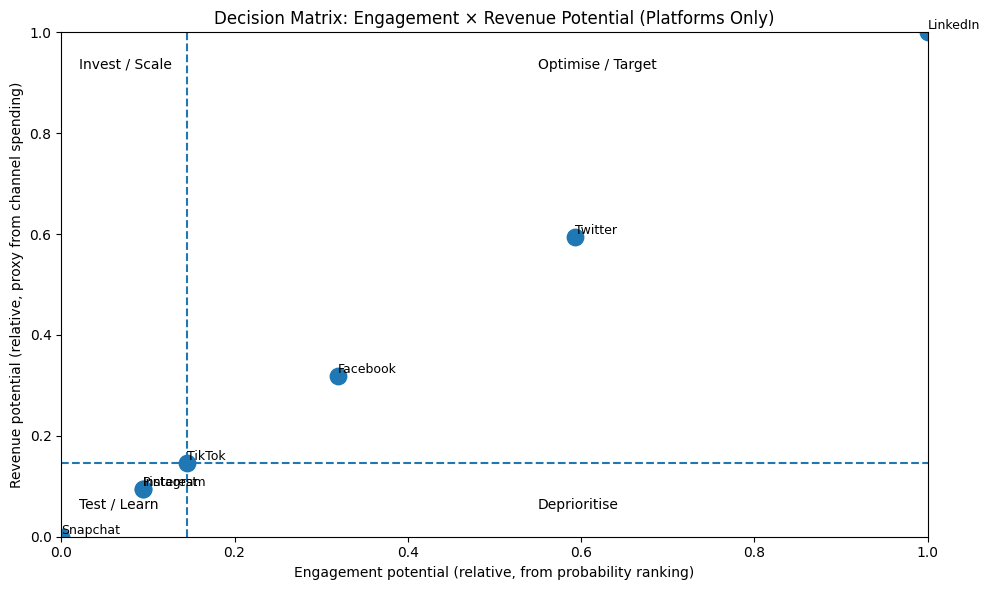

,Platform,P_High_Engagement,eng_norm,rev_proxy,rev_norm
2,LinkedIn,0.756098,1.000000,0.347260,1.000000
6,Twitter,0.578947,0.593305,0.265899,0.593305
0,Facebook,0.459459,0.318989,0.211020,0.318989
5,TikTok,0.383838,0.145381,0.176289,0.145381
3,Pinterest,0.361702,0.094561,0.166122,0.094561
1,Instagram,0.361446,0.093972,0.166005,0.093972
4,Snapchat,0.320513,0.000000,0.147205,0.000000


,Channel,Avg_Spending,channel_score
1,Mixed,279.895176,1.000000
2,Online,274.264162,0.377839
0,In-Store,270.844448,0.000000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Preconditions
# =========================
assert 'prob_df' in globals(), "prob_df is required (run Chart 1 first)."
assert ecom_df is not None, "ecom_df is required."
assert col_channel is not None and col_amount is not None, "col_channel and col_amount must be detected."

# =========================
# 1) Engagement (X-axis) from Chart 1
# =========================
platforms = prob_df[["Platform", "P_High_Engagement"]].copy()

# Normalize engagement to 0-1
platforms["eng_norm"] = (platforms["P_High_Engagement"] - platforms["P_High_Engagement"].min()) / (
    platforms["P_High_Engagement"].max() - platforms["P_High_Engagement"].min() + 1e-9
)

# =========================
# 2) Revenue proxy (Y-axis) from ecommerce channel spending
#    (NO fake mapping of platform->channel)
# =========================
channel_rev = (
    ecom_df
    .dropna(subset=[col_channel, col_amount])
    .groupby(col_channel)[col_amount]
    .mean()
    .reset_index()
    .rename(columns={col_channel: "Channel", col_amount: "Avg_Spending"})
)

# Normalize channel spending to 0-1
channel_rev["channel_score"] = (channel_rev["Avg_Spending"] - channel_rev["Avg_Spending"].min()) / (
    channel_rev["Avg_Spending"].max() - channel_rev["Avg_Spending"].min() + 1e-9
)

# Revenue benchmark score:
# Use mean channel score (stable + conservative). You can change to max() if you want "best-case".
overall_channel_score = channel_rev["channel_score"].mean()

# Revenue proxy per platform:
# Higher engagement increases the capacity to drive traffic into revenue-generating channels.
platforms["rev_proxy"] = platforms["P_High_Engagement"] * overall_channel_score

# Normalize revenue proxy to 0-1
platforms["rev_norm"] = (platforms["rev_proxy"] - platforms["rev_proxy"].min()) / (
    platforms["rev_proxy"].max() - platforms["rev_proxy"].min() + 1e-9
)

# =========================
# 3) Decision Matrix plot (Platforms only)
# =========================
x_mid = platforms["eng_norm"].median()
y_mid = platforms["rev_norm"].median()

plt.figure(figsize=(10, 6))
plt.scatter(platforms["eng_norm"], platforms["rev_norm"], s=140)

# Label each platform
for _, r in platforms.iterrows():
    plt.text(r["eng_norm"], r["rev_norm"], r["Platform"], fontsize=9, ha="left", va="bottom")

# Quadrant split
plt.axvline(x=x_mid, linestyle="--")
plt.axhline(y=y_mid, linestyle="--")

# Quadrant labels (simple + business-ready)
plt.text(0.02, 0.95, "Invest / Scale", fontsize=10, va="top")
plt.text(0.55, 0.95, "Optimise / Target", fontsize=10, va="top")
plt.text(0.02, 0.05, "Test / Learn", fontsize=10, va="bottom")
plt.text(0.55, 0.05, "Deprioritise", fontsize=10, va="bottom")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Engagement potential (relative, from probability ranking)")
plt.ylabel("Revenue potential (relative, proxy from channel spending)")
plt.title("Decision Matrix: Engagement × Revenue Potential (Platforms Only)")
plt.tight_layout()
plt.savefig("A3_chart2_decision_matrix_platforms_only.png", dpi=300)
plt.show()

# Output tables (useful for report writing)
display(platforms.sort_values(["rev_proxy", "P_High_Engagement"], ascending=False))
display(channel_rev.sort_values("Avg_Spending", ascending=False))


##3. Before-After budget allocation mock-up

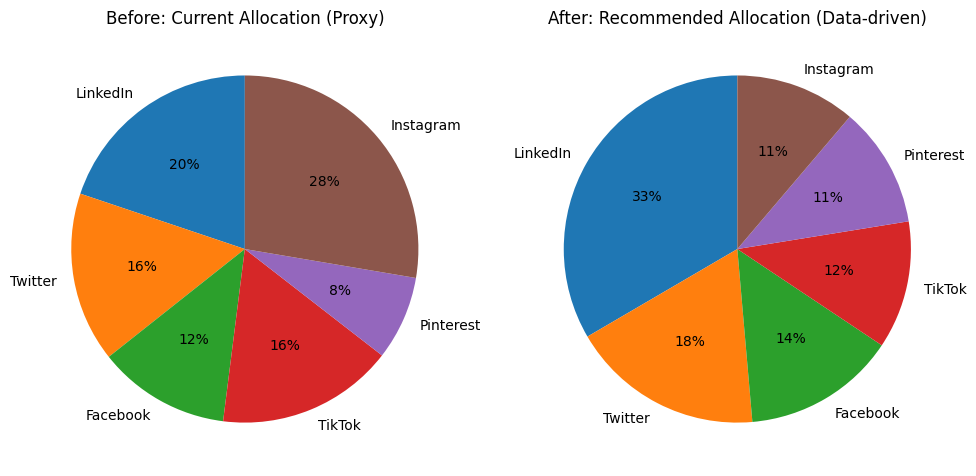

,Before_%,After_%
LinkedIn,6.83,23.47
Twitter,15.83,17.97
Facebook,12.33,14.26
TikTok,16.50,11.91
Pinterest,7.83,11.23
Instagram,27.67,11.22


In [ ]:
# --- Chart 3: Before vs After budget allocation ---

# Ensure required data and columns are available
assert social_df is not None, "social_df is not defined. Please load and prepare the social media dataset first."
assert col_platform is not None, "Platform column could not be detected in social_df."

# BEFORE: Frequency-based proxy for current allocation
before = (
    social_df[col_platform]
    .dropna()
    .value_counts(normalize=True)
    .mul(100)
)

# AFTER: Data-driven allocation based on probability ranking from Chart 1
after = prob_df.set_index("Platform")["P_High_Engagement"]
after = (after / after.sum() * 100)

# Keep top platforms for readability
keep = prob_df["Platform"].head(6).tolist()
before_keep = before.reindex(keep).fillna(0)
after_keep  = after.reindex(keep).fillna(0)

def _fix_to_100(arr):
    """Adjust percentages to ensure they sum exactly to 100% (handles rounding)."""
    arr = np.array(arr, dtype=float)
    diff = 100 - arr.sum()
    if len(arr) > 0:
        arr[0] += diff
    return arr

labels = keep
before_pct = _fix_to_100(before_keep.values)
after_pct  = _fix_to_100(after_keep.values)

# Plot Before vs After pie charts
fig = plt.figure(figsize=(10, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.pie(before_pct, labels=labels, autopct="%1.0f%%", startangle=90)
ax1.set_title("Before: Current Allocation (Proxy)")

ax2 = fig.add_subplot(1, 2, 2)
ax2.pie(after_pct, labels=labels, autopct="%1.0f%%", startangle=90)
ax2.set_title("After: Recommended Allocation (Data-driven)")

plt.tight_layout()
plt.savefig("A3_chart3_budget_before_after.png", dpi=300)
plt.show()

# Display comparison table
pd.DataFrame({
    "Before_%": before_keep.round(2),
    "After_%": after_keep.round(2)
}).sort_values("After_%", ascending=False)
